# [天池] 用户情感可视化分析

[比赛链接](https://tianchi.aliyun.com/competition/entrance/531890/introduction)

[测试语料 earphone_sentiment.csv](https://dl2.grepcode.cn/dataset/earphone_sentiment.csv)

> 
>   To Do： 完成下面任意一种可视化分析
>
>   1）词云可视化（评论中的关键词，不同情感的词云）
>
>   2）柱状图（不同主题，不同情感，不同情感词）
>
>   3）相关性系数热力图（不同主题，不同情感，不同情感词）
>

<div class="alert alert-block alert-danger">
无法理解第二问和第三问的要求
</div>


In [98]:
!/opt/py38/bin/pip install wordcloud
!/opt/py38/bin/pip install jieba

Looking in indexes: https://mirrors.aliyun.com/pypi/simple/
Looking in indexes: https://mirrors.aliyun.com/pypi/simple/


In [99]:
import pandas as pd
#创建词云函数
from wordcloud import WordCloud
import matplotlib.pyplot as plt
import jieba

data = pd.read_csv('/home/stdhi/dataset/earphone_sentiment.csv')
print(data.shape)
data

(17176, 5)


,content_id,content,subject,sentiment_word,sentiment_value
0,0,Silent Angel期待您的光临，共赏美好的声音！,其他,好,1
1,2,这只HD650在1k的失真左声道是右声道的6倍左右，也超出官方规格参数范围（0.05%），看...,其他,NaN,0
2,3,达音科 17周年 倒是数据最好看，而且便宜,配置,好,1
3,4,bose，beats，apple的消費者根本不知道有曲線的存在,其他,NaN,0
4,5,不错的数据,配置,不错,1
...,...,...,...,...,...
17171,17200,3000价位推hd650有比S7更好的耳放么,其他,好,1
17172,17201,hd800爆皮正常，换根线就没这种忧虑了,配置,NaN,0
17173,17202,自己焊接一下就行了，话说我820原线全新，800s原线99新，放盒子里没动了,配置,NaN,0
17174,17203,所以趁着还没爆，赶紧出手。,其他,NaN,0


In [100]:
#去掉停用词，虚词（你好，我的，等）
def remove_stop_words(f):
    #stop_words=["好", "不错", "不", "差", "呵呵", " "] #需要去掉的停用词
    stop_words = ["好", " "]
    f = [x for x in f if x not in stop_words]
    return f

# 读取用户情感字段
data1=data[data['sentiment_word'].notna()] #去除情感字段为空数据行
all_sentiment_word = " ".join(str(i) for i in data1["sentiment_word"])

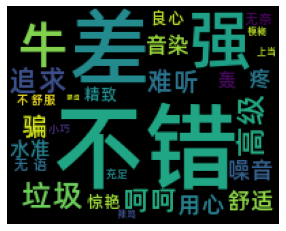

In [101]:
def create_word_cloud(f):
    cut_text = jieba.lcut(f) #生成list
    cut_text = remove_stop_words(cut_text)
    cut_text = " ".join(cut_text)
    wc = WordCloud(
        max_words=100,
        width=200,
        height=160,
       font_path='/home/stdhi/dataset/Alibaba-PuHuiTi-Medium.ttf'
    )
    
    wordcloud = wc.generate(cut_text)
    wordcloud.to_file("car_wordcloud.jpg")
    # 显示词云图片
    plt.imshow(wordcloud)
    plt.axis("off")
    plt.show()
    
# 生成词云
create_word_cloud(all_sentiment_word)    

In [102]:
def create_word_pillar(f):
    cut_text = jieba.lcut(f) #生成list
    cut_text = remove_stop_words(cut_text)
    pillar = {}
    for i in cut_text:
        pillar[i] = cut_text.count(i)
    print(pillar)
    return
    
    wordcloud = wc.generate(cut_text)
    wordcloud.to_file("car_wordcloud.jpg")
    # 显示词云图片
    plt.imshow(wordcloud)
    plt.axis("off")
    plt.show()
    
create_word_pillar(all_sentiment_word)    

{'不错': 569, '呵呵': 24, '牛': 133, '差': 415, '疼': 14, '强': 244, '骗': 21, '高级': 31, '精致': 7, '无': 6, '语': 6, '水准': 12, '垃圾': 32, '难听': 22, '舒适': 16, '用心': 16, '追求': 26, '噪音': 16, '轰': 10, '不': 4, '舒服': 4, '小巧': 3, '音染': 14, '惊艳': 7, '充足': 3, '上当': 2, '无奈': 5, '良心': 7, '混浊': 1, '辣鸡': 2, '模糊': 2}
